# 🗑️ Smart Recycling Bin — CNN per la classificazione dei rifiuti

> **Obiettivo:** addestrare una rete neurale convoluzionale (CNN) che, vista la foto di un oggetto, decide in quale bidone va: **Plastica 🟡 · Carta 🔵 · Vetro 🟢 · Metallo ⚪**

---
Questo notebook è pensato per essere eseguito su **Google Colab** (GPU gratuita inclusa).  
Esegui le celle **in ordine** — ogni blocco ha una spiegazione dedicata.

---
## 📦 Slide 1 — Installazione e import

**Cosa fa questa cella:**  
Installa le librerie necessarie e le importa. Su Colab `torch` e `torchvision` sono già presenti; installiamo solo `kagglehub` per scaricare il dataset.

| Libreria | Scopo |
|---|---|
| `torch` / `torchvision` | Costruire e addestrare la rete neurale |
| `matplotlib` | Visualizzare immagini e grafici |
| `numpy` | Calcoli numerici |
| `kagglehub` | Scaricare dataset da Kaggle |

In [1]:
%pip install torch

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install numpy

Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [4]:
%pip install torchvision

Note: you may need to restart the kernel to use updated packages.


In [5]:
# ── Installazione ──────────────────────────────────────────────────────────────
# !pip install kagglehub  # decommenta se vuoi usare Kaggle come sorgente dati

# ── Import standard ───────────────────────────────────────────────────────────
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

# ── Riproducibilità ────────────────────────────────────────────────────────────
# Impostiamo un seed fisso: così ogni volta che rieseguiamo il notebook
# otteniamo gli stessi risultati (utile per debug e confronti).
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Dispositivo ────────────────────────────────────────────────────────────────
# Se Colab ha una GPU disponibile la usiamo: è molto più veloce della CPU.
# "cuda" = GPU NVIDIA  |  "cpu" = processore normale
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo in uso: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Dispositivo in uso: cpu


---
## 🗂️ Slide 2 — Dataset e Data Augmentation

Usiamo il dataset **[TrashNet](https://github.com/garythung/trashnet)** (≈2500 foto di rifiuti reali).  
Noi lo simuliamo con `ImageFolder`: basta avere una cartella per ogni classe.

```
dataset/
  plastica/   🟡  (bottiglie, sacchetti)
  carta/      🔵  (scatole, giornali)
  vetro/      🟢  (bottiglie, barattoli)
  metallo/    ⚪  (lattine, fogli)
```

### Cos'è la Data Augmentation?
Non abbiamo milioni di foto → **creiamo varianti artificiali** di quelle che abbiamo.  
Ogni volta che la rete vede un'immagine durante il training, la trasformazione è **casuale e diversa**:

| Trasformazione | Perché? |
|---|---|
| `RandomHorizontalFlip` | Una lattina è una lattina anche capovolta |
| `RandomRotation(30°)` | Un oggetto può essere ruotato nel bidone |
| `ColorJitter` | Luci diverse, foto sfocate — la rete deve resistere |
| `RandomResizedCrop` | L'oggetto può essere parzialmente visibile |

> **Nota:** la Data Augmentation si applica **solo al training set**, MAI al validation/test set (lì vogliamo misure stabili).

In [6]:
%pip install kagglehub

Note: you may need to restart the kernel to use updated packages.


In [7]:
import torch                                                                                                
import torch.nn as nn                                                                                       
from torchvision.models import mobilenet_v2                                                                 
import torchvision.transforms as transforms                                                                 
from PIL import Image                                                                                       
                                                                                                              
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")                                       
                  
  # ── Ricarica il checkpoint ────────────────────────────────────────────────────                            
checkpoint = torch.load("smart_recycling_bin.pth", map_location=device, weights_only=False)
CLASSES = checkpoint["classes"]                                                                             
NUM_CLASSES = len(CLASSES)                                                                                  
                                                                                                              
  # ── Ricostruisci la STESSA architettura usata in training ─────────────────────                            
 # ... (le tue import e il caricamento del checkpoint rimangono uguali)

# ── Ricostruisci la STESSA architettura ─────────────────────
model = mobilenet_v2(weights=None) 

    # Il classificatore deve contenere TUTTI i layer, incluso l'ultimo
model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),            # Indice 0
        nn.Linear(1280, 256),         # Indice 1
        nn.ReLU(),                    # Indice 2
        nn.Dropout(p=0.3),            # Indice 3
        nn.Linear(256, NUM_CLASSES)   # Indice 4: QUESTO mancava dentro la parentesi!
    )

    # ── Carica i pesi addestrati ─────────────────────────────────
model.load_state_dict(checkpoint["model_state_dict"]) 
model = model.to(device)
model.eval()

print(f"Modello caricato correttamente. Classi: {CLASSES}")
print(f"Test accuracy del training: {checkpoint['test_accuracy']:.2%}")

Modello caricato correttamente. Classi: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Test accuracy del training: 79.74%


In [8]:
  IMG_SIZE = 224                                                                                              
                  
  preprocess = transforms.Compose([
      transforms.Resize((IMG_SIZE, IMG_SIZE)),
      transforms.ToTensor(),                                                                                  
      transforms.Normalize(mean=[0.485, 0.456, 0.406],                                                        
                           std=[0.229, 0.224, 0.225]),                                                        
  ])                                                                                                          
                                                                                                              
  def predict(image_path):
      img = Image.open(image_path).convert("RGB")                                                             
      x = preprocess(img).unsqueeze(0).to(device)                                                             
                                                                                                              
      with torch.no_grad():                                                                                   
          probs = torch.softmax(model(x), dim=1)[0]                                                           
                                                                                                              
      idx = probs.argmax().item()
      return {                                                                                                
          "classe": CLASSES[idx],
          "confidenza": probs[idx].item(),                                                                    
          "tutte_le_probabilita": {c: float(p) for c, p in zip(CLASSES, probs)},                              
      }

SOLO AL PRIMO TRAINING

In [9]:
  # ── Iperparametri globali ──────────────────────────────────────────────────────
  IMG_SIZE   = 224   # tutte le immagini ridimensionate a 224×224 pixel                                       
  BATCH_SIZE = 32    # quante immagini vede la rete per ogni step di training                                 
                                                                                                              
  # ── Trasformazioni per il TRAINING (con augmentation) ─────────────────────────                            
  train_transform = transforms.Compose([                                                                      
      transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),                                               
      transforms.RandomHorizontalFlip(),                                                                      
      transforms.RandomRotation(30),                                                                          
      transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),                                   
      transforms.ToTensor(),                                                                                  
      transforms.Normalize(mean=[0.485, 0.456, 0.406],                                                        
                           std=[0.229, 0.224, 0.225]),                                                        
  ])                                                                                                          
                                                                                                              
  # ── Trasformazioni per VALIDATION/TEST (deterministiche, no augmentation) ─────                            
  val_transform = transforms.Compose([
      transforms.Resize((IMG_SIZE, IMG_SIZE)),                                                                
      transforms.ToTensor(),                                                                                  
      transforms.Normalize(mean=[0.485, 0.456, 0.406],                                                        
                           std=[0.229, 0.224, 0.225]),                                                        
  ])                                                                                                          
                                                                                                              
  # ── Download dataset reale da Kaggle ───────────────────────────────────────────                           
  # Se non hai kagglehub installato: esegui  !pip install -q kagglehub  in una cella a parte.
  import kagglehub                                                                                            
                  
  dataset_path = kagglehub.dataset_download("feyzazkefe/trashnet")                                            
  print("Scaricato in:", dataset_path)
                                                                                                              
  # A volte kagglehub scarica con una cartella padre in più (es. .../dataset-resized/cardboard/...)           
  # Troviamo automaticamente la directory che contiene le sottocartelle per classe.                           
  def find_image_root(base):                                                                                  
      for root, dirs, files in os.walk(base):                                                                 
          # cerchiamo una cartella che contiene SOLO sottocartelle (le classi) con immagini                   
          if dirs and all(                                                                                    
              any(f.lower().endswith((".jpg", ".jpeg", ".png"))                                               
                  for f in os.listdir(os.path.join(root, d)))                                                 
              for d in dirs                                                                                   
          ):                                                                                                  
              return root                                                                                     
      return base                                                                                             
   
  image_root = find_image_root(dataset_path)                                                                  
  print("Root delle classi:", image_root)
                                                                                                              
  # ── ImageFolder + classi dinamiche ─────────────────────────────────────────────                           
  full_dataset = ImageFolder(root=image_root, transform=train_transform)                                      
  CLASSES     = full_dataset.classes                                                                          
  NUM_CLASSES = len(CLASSES)
  print(f"Classi rilevate ({NUM_CLASSES}):", CLASSES)                                                         
                                                                                                              
  # ── Split train / val / test (70 / 15 / 15) ────────────────────────────────────                           
  n_total = len(full_dataset)                                                                                 
  n_train = int(0.70 * n_total)                                                                               
  n_val   = int(0.15 * n_total)
  n_test  = n_total - n_train - n_val                                                                         
                                                                                                              
  train_set, val_set, test_set = random_split(                                                                
      full_dataset, [n_train, n_val, n_test],                                                                 
      generator=torch.Generator().manual_seed(SEED),                                                          
  )                                                                                                           
                                                                                                              
  # ── Applica val_transform solo a val e test (senza augmentation casuale) ──────                            
  # random_split condivide lo stesso dataset sottostante: cloniamo per cambiargli il transform.
  from copy import copy                                                                                       
  val_set.dataset  = copy(val_set.dataset);   val_set.dataset.transform  = val_transform
  test_set.dataset = copy(test_set.dataset);  test_set.dataset.transform = val_transform                      
                                                                                                              
  # ── DataLoader ─────────────────────────────────────────────────────────────────                           
  train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)                   
  val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)                   
  test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)                   
                                                                                                              
  print(f"\nDataset: {n_total} immagini totali")                                                              
  print(f"  Training:   {n_train}")                                                                           
  print(f"  Validation: {n_val}")                                                                             
  print(f"  Test:       {n_test}")

Scaricato in: C:\Users\LorenzoBortoluzzi\.cache\kagglehub\datasets\feyzazkefe\trashnet\versions\1
Root delle classi: C:\Users\LorenzoBortoluzzi\.cache\kagglehub\datasets\feyzazkefe\trashnet\versions\1\dataset-resized
Classi rilevate (6): ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

Dataset: 2527 immagini totali
  Training:   1768
  Validation: 379
  Test:       380


---
## 🧠 Slide 3 — Architettura della CNN (il modello)

Usiamo **Transfer Learning** con `MobileNetV2` pre-addestrato su ImageNet.  
Invece di addestrare da zero (servirebbero milioni di foto e ore di GPU), **prendiamo in prestito** i layer convoluzionali già addestrati e cambiamo solo l'ultimo strato.

```
INPUT (224×224 foto)
    │
    ▼
LAYER 1 – Bordi: rileva linee, curve, spigoli
    │
    ▼  
LAYER 2 – Texture: trasparenza vetro vs opacità cartone
    │
    ▼
LAYER N – Forme astratte: "silhouette di lattina", "forma di bottiglia"
    │
    ▼
DROPOUT (30%) ← regolarizzazione: spegne neuroni casuali
    │
    ▼
FULLY CONNECTED → 4 classi (plastica/carta/vetro/metallo)
    │
    ▼
SOFTMAX → probabilità [0.80, 0.01, 0.04, 0.15]
```

### Perché il Dropout?
Come spiegato nel `dropout.ipynb`: spegnere neuroni casualmente durante il training impedisce alla rete di **imparare a memoria** i rifiuti del training set (overfitting). In fase di predizione (`.eval()`) il dropout è automaticamente disattivato.

In [10]:
# ── Transfer Learning con MobileNetV2 ─────────────────────────────────────────
# MobileNetV2 è una CNN leggera ottima per demo e dispositivi mobili.
# weights=DEFAULT carica i pesi pre-addestrati su ImageNet (1000 classi).

from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

model = mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)

# ── Freeze dei layer convoluzionali ───────────────────────────────────────────
# "Congelo" i pesi pre-addestrati: voglio che imparino solo i layer finali.
# Così il training è molto più veloce (pochi parametri da aggiornare).
for param in model.parameters():
    param.requires_grad = False   # non calcolare il gradiente per questi

# ── Sostituzione del classificatore finale ────────────────────────────────────
# MobileNetV2 termina con un layer lineare 1280→1000 (per ImageNet).
# Lo sostituiamo con il nostro classificatore per 4 classi.
#
# Struttura del nostro classificatore:
#   Dropout(0.3)          → spegne il 30% dei neuroni durante training
#   Linear(1280, 256)     → strato nascosto intermedio
#   ReLU()                → funzione di attivazione non lineare
#   Dropout(0.3)          → secondo dropout per più robustezza
#   Linear(256, 4)        → output: 4 classi (NO softmax qui!)
#                           la CrossEntropyLoss la include già internamente

model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),           # vedi: dropout.ipynb
    nn.Linear(1280, 256),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(256, NUM_CLASSES), # ← ultimo strato: no attivazione (come in Lezione 1)
)

# Sposta il modello sul dispositivo scelto (GPU se disponibile)
model = model.to(device)

# ── Riepilogo parametri ────────────────────────────────────────────────────────
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parametri totali:     {total_params:,}")
print(f"Parametri addestrabili: {trainable_params:,}")
print(f"Parametri congelati:  {total_params - trainable_params:,}")
print(f"\nClassificatore finale:")
print(model.classifier)

Parametri totali:     2,553,350
Parametri addestrabili: 329,478
Parametri congelati:  2,223,872

Classificatore finale:
Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=1280, out_features=256, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.3, inplace=False)
  (4): Linear(in_features=256, out_features=6, bias=True)
)


---
## ⚙️ Slide 4 — Loss function e Optimizer

Come spiegato nella **Lezione 1 (sezione 7)**:

- **Loss function**: misura quanto la predizione è lontana dal target.
  - Per classificazione multiclasse → **CrossEntropyLoss** (la stessa del notebook).
  - Formula: `L = -log(P_classe_corretta)`
  
- **Optimizer**: aggiorna i pesi nella direzione opposta al gradiente.
  - **Adam**: una versione avanzata della discesa del gradiente (sezione 8 della Lezione 1).
  - Gestisce automaticamente il learning rate per ogni parametro.

- **Learning Rate Scheduler**: riduce il learning rate nel tempo.  
  Inizialmente passi grandi per convergere veloce → poi passi piccoli per rifinire.

In [11]:
# ── Loss function ─────────────────────────────────────────────────────────────
# CrossEntropyLoss è la funzione di costo per classificazione multiclasse.
# Internamente combina: Softmax + NegativeLogLikelihoodLoss
# Quindi NON aggiungere Softmax nell'ultimo layer del modello!
criterion = nn.CrossEntropyLoss()

# ── Optimizer ─────────────────────────────────────────────────────────────────
# Adam è l'ottimizzatore più usato nel Deep Learning:
#   - Adatta il learning rate per ogni parametro
#   - Converge più velocemente della semplice discesa del gradiente
#
# Passiamo SOLO i parametri con requires_grad=True (quelli del classificatore).
# weight_decay è una tecnica di regolarizzazione aggiuntiva (L2 regularization).
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,          # learning rate iniziale: 0.001
    weight_decay=1e-4 # penalizza pesi troppo grandi (riduce overfitting)
)

# ── Learning Rate Scheduler ───────────────────────────────────────────────────
# StepLR: dimezza il learning rate ogni 5 epoche
#   epoca 1-5:   lr = 0.001
#   epoca 6-10:  lr = 0.0005
#   epoca 11-15: lr = 0.00025  ... ecc.
NUM_EPOCHS = 15
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

print(f"Loss:      CrossEntropyLoss")
print(f"Optimizer: Adam (lr={1e-3}, weight_decay={1e-4})")
print(f"Scheduler: StepLR (step=5, gamma=0.5)")
print(f"Epoche:    {NUM_EPOCHS}")

Loss:      CrossEntropyLoss
Optimizer: Adam (lr=0.001, weight_decay=0.0001)
Scheduler: StepLR (step=5, gamma=0.5)
Epoche:    15


---
## 🏋️ Slide 5 — Training loop

Il **training loop** è il cuore del processo di apprendimento. Per ogni epoca:

1. **Forward pass**: l'immagine attraversa la rete → otteniamo i logit (predizioni grezze)
2. **Calcolo della loss**: confrontiamo predizione vs etichetta reale
3. **Backward pass** (backpropagation): calcoliamo i gradienti rispetto a tutti i pesi
4. **Update**: l'optimizer aggiorna i pesi: `w = w - η · ∇L`
5. **Validation**: valutiamo sul validation set (dropout disattivato, no gradiente)

> Ricorda: `model.train()` attiva dropout · `model.eval()` lo disattiva

In [12]:
def evaluate(model, loader):
    """Calcola loss e accuracy su un DataLoader (senza aggiornare i pesi)."""
    model.eval()  
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)              
            loss   = criterion(logits, labels)  

            total_loss += loss.item() * images.size(0)
            preds = logits.argmax(dim=1)        
            correct += (preds == labels).sum().item()
            total   += images.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

print(f"{'Epoca':>5} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>7} | {'LR':>8}")
print("-" * 65)

for epoch in range(1, NUM_EPOCHS + 1):

    model.train()  
    train_loss, train_correct, train_total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        logits = model(images)

        loss = criterion(logits, labels)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        train_loss    += loss.item() * images.size(0)
        preds          = logits.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total   += images.size(0)

    train_loss /= train_total
    train_acc   = train_correct / train_total

    val_loss, val_acc = evaluate(model, val_loader)

    scheduler.step()   
    current_lr = scheduler.get_last_lr()[0]

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"{epoch:>5} | {train_loss:>10.4f} | {train_acc:>9.2%} | {val_loss:>8.4f} | {val_acc:>7.2%} | {current_lr:>8.6f}")

print("\nTraining completato!")

Epoca | Train Loss | Train Acc | Val Loss | Val Acc |       LR
-----------------------------------------------------------------
    1 |     1.2258 |    54.36% |   0.8836 |  72.30% | 0.001000
    2 |     0.7985 |    71.72% |   0.7178 |  75.73% | 0.001000
    3 |     0.7235 |    74.94% |   0.6193 |  79.16% | 0.001000
    4 |     0.6460 |    76.30% |   0.5465 |  79.42% | 0.001000
    5 |     0.5922 |    77.77% |   0.5872 |  78.89% | 0.000500
    6 |     0.5812 |    79.02% |   0.5128 |  80.74% | 0.000500
    7 |     0.5590 |    79.69% |   0.5158 |  81.53% | 0.000500
    8 |     0.5574 |    80.15% |   0.5040 |  82.59% | 0.000500
    9 |     0.5206 |    80.60% |   0.5021 |  82.59% | 0.000500
   10 |     0.5056 |    81.05% |   0.5512 |  79.68% | 0.000250
   11 |     0.5318 |    79.81% |   0.5033 |  82.32% | 0.000250
   12 |     0.4939 |    81.90% |   0.5040 |  83.38% | 0.000250
   13 |     0.5083 |    80.77% |   0.4875 |  82.85% | 0.000250
   14 |     0.4917 |    82.13% |   0.4831 |  83.38% 

---
## 📊 Slide 6 — Visualizzazione delle curve di apprendimento

Le **learning curves** mostrano come cambia la loss e l'accuracy durante il training.

**Come interpretarle:**
- ✅ **Buono**: train_loss e val_loss scendono insieme → la rete sta imparando
- ⚠️ **Overfitting**: train_loss scende ma val_loss sale → la rete memorizza i dati
- ⚠️ **Underfitting**: entrambe le loss restano alte → il modello è troppo semplice

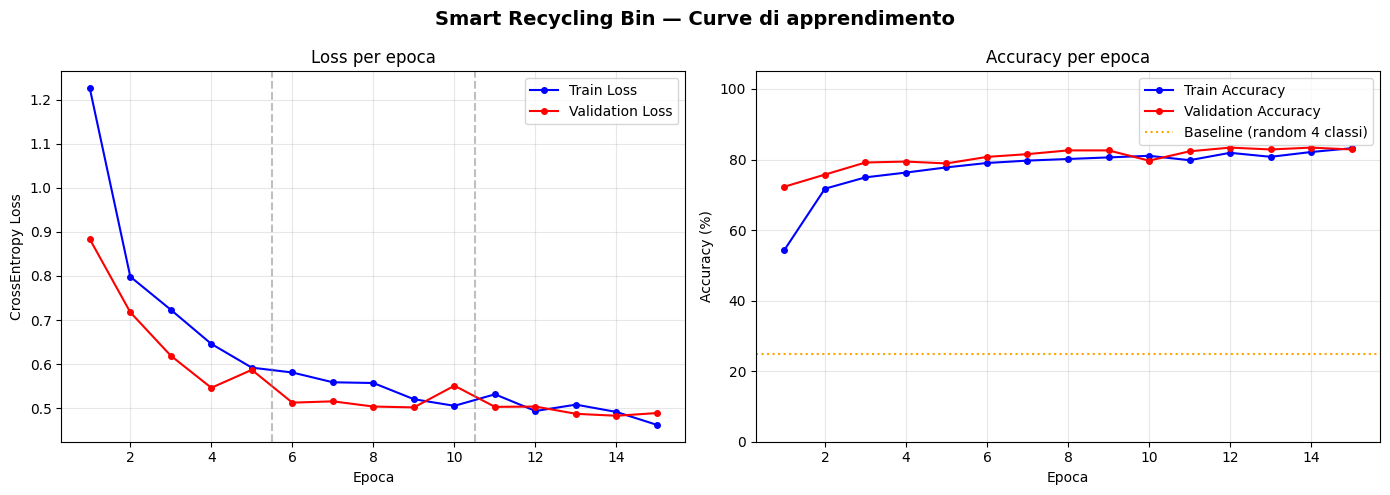

Grafico salvato come 'learning_curves.png'


In [13]:
epochs_range = range(1, NUM_EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Smart Recycling Bin — Curve di apprendimento", fontsize=14, fontweight="bold")

# ── Grafico 1: Loss ───────────────────────────────────────────────────────────
ax1.plot(epochs_range, history["train_loss"], "b-o", label="Train Loss",      markersize=4)
ax1.plot(epochs_range, history["val_loss"],   "r-o", label="Validation Loss", markersize=4)
ax1.set_title("Loss per epoca")
ax1.set_xlabel("Epoca")
ax1.set_ylabel("CrossEntropy Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)
# Linea verticale ogni 5 epoche (quando il lr viene dimezzato)
for step in [5, 10]:
    ax1.axvline(x=step + 0.5, color="gray", linestyle="--", alpha=0.5, label=f"lr dimezzato")

# ── Grafico 2: Accuracy ───────────────────────────────────────────────────────
ax2.plot(epochs_range, [a * 100 for a in history["train_acc"]], "b-o", label="Train Accuracy",      markersize=4)
ax2.plot(epochs_range, [a * 100 for a in history["val_acc"]],   "r-o", label="Validation Accuracy", markersize=4)
ax2.set_title("Accuracy per epoca")
ax2.set_xlabel("Epoca")
ax2.set_ylabel("Accuracy (%)")
ax2.set_ylim(0, 105)
ax2.axhline(y=25, color="orange", linestyle=":", label="Baseline (random 4 classi)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafico salvato come 'learning_curves.png'")

---
## 🧪 Slide 7 — Valutazione sul Test Set

Il **test set** non è mai stato visto durante il training o la validation.  
È il nostro metro di giudizio finale: simula le foto reali che il bidone riceverà.

La **Confusion Matrix** mostra:
- **Diagonale**: predizioni corrette ✅
- **Fuori diagonale**: errori ❌ (es. ha scambiato vetro per plastica)

In [14]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



=== RISULTATI SUL TEST SET ===
Accuracy finale: 79.74%

              precision    recall  f1-score   support

   cardboard       0.96      0.80      0.87        59
       glass       0.86      0.79      0.83        78
       metal       0.69      0.82      0.75        61
       paper       0.86      0.87      0.86        92
     plastic       0.68      0.80      0.74        66
       trash       0.69      0.46      0.55        24

    accuracy                           0.80       380
   macro avg       0.79      0.76      0.77       380
weighted avg       0.81      0.80      0.80       380



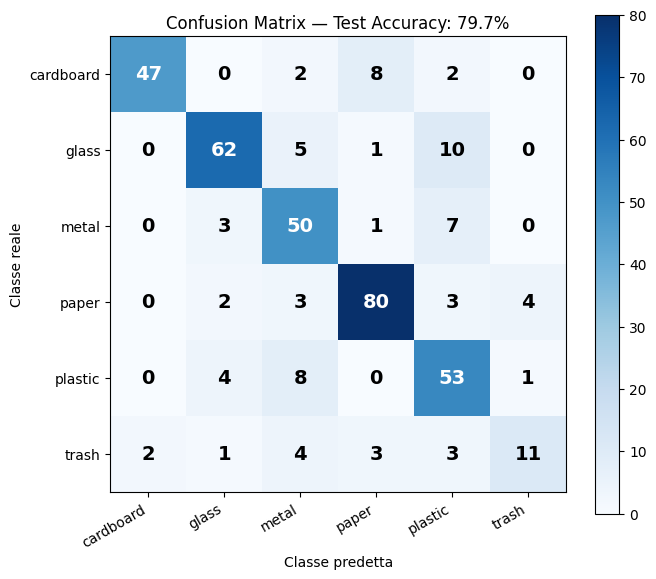

In [15]:
from sklearn.metrics import confusion_matrix, classification_report
import itertools

# ── Raccolta di tutte le predizioni sul test set ───────────────────────────────
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        logits = model(images)
        preds  = logits.argmax(dim=1).cpu()  # indice della classe con prob massima
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
test_acc   = (all_preds == all_labels).mean()

print(f"\n=== RISULTATI SUL TEST SET ===")
print(f"Accuracy finale: {test_acc:.2%}\n")
print(classification_report(all_labels, all_preds, target_names=CLASSES))

# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.colorbar(im, ax=ax)

ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASSES, rotation=30, ha="right")
ax.set_yticklabels(CLASSES)
ax.set_xlabel("Classe predetta")
ax.set_ylabel("Classe reale")
ax.set_title(f"Confusion Matrix — Test Accuracy: {test_acc:.1%}")

# Annotazioni nelle celle
thresh = cm.max() / 2
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    ax.text(j, i, str(cm[i, j]),
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black",
            fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 🎬 Slide 8 — Il "Live Show": predizione su foto reale

Questa è la parte più spettacolare della presentazione.  
Caricate una foto presa con il vostro telefono e vedete cosa decide la rete.

**Come fare:**
1. Scattate una foto a un oggetto (es. una bottiglia d'acqua)
2. Caricatela su Colab: menu `File → Upload to session storage`
3. Cambiate `IMAGE_PATH` con il nome del file
4. Eseguite la cella → vedete la predizione!

Se non avete una foto, la cella genera automaticamente un'immagine casuale per testare.

In [16]:
img_paper = "Gerstaecker+-+Carta+da+disegno+A3+per+la+scuola.avif"   # ← cambia con il path della tua foto!
img_glass = "bottiglia-verde-lt1-mod-vichy.jpg"
img_plastic = "902104_2.jpg"
img_metal = "bidone-di-ferro-realistico-con-composizione-di-rifiuti-di-due-viste-isolate-di-bidoni-della-spazzatura-in-metallo-con-illustrazione-vettoriale-dei-rifiuti_1284-79166.avif"
IMAGE_PATH = img_plastic = "902104_2.jpg"


In [ ]:
import cv2
from PIL import Image                                                                                       
import matplotlib.pyplot as plt                                                                               
                                                                                                            
OUTPUT_PATH = "bottiglia-verde-lt1-mod-vichy.jpg"                                                                   
                                                                                                            
cap = cv2.VideoCapture(0)                                                  
if not cap.isOpened():                                                                                    
    raise RuntimeError("Impossibile aprire la webcam.")                                                     
                                                                                                        
print("SPAZIO = scatta | ESC = annulla")                                                                    
captured = False                                                                                          
while True:                                                                                                 
    ret, frame = cap.read()                                                                               
    if not ret:                                                                                             
        break                                                                                             
            
    display = frame.copy()                                                                                  
    cv2.putText(display, "SPAZIO = scatta | ESC = annulla",
                (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)                                    
    cv2.imshow("Smart Recycling Bin - Webcam", display)                                                     
                                                                                                            
    key = cv2.waitKey(1) & 0xFF                                                                             
    if key == 27:      # ESC                                                                                
        break                                                                                             
    elif key == 32:    # SPAZIO                                                                             
        cv2.imwrite(OUTPUT_PATH, frame)
        captured = True                                                                                     
        print(f"Foto salvata: {OUTPUT_PATH}")                                                               
        break                                                                                               
                                                                                                            
cap.release()                                                                                               
cv2.destroyAllWindows()                                                                                     
                        
if captured:
    img_captured = Image.open(OUTPUT_PATH).convert("RGB")                                                   
    plt.figure(figsize=(6, 5))                           
    plt.imshow(img_captured); plt.axis("off"); plt.title("Foto catturata")                                  
    plt.show()                                                            
    IMAGE_PATH = OUTPUT_PATH                                           

SPAZIO = scatta | ESC = annulla


Foto caricata: 902104_2.jpg


C:\Users\LorenzoBortoluzzi\AppData\Local\Temp\ipykernel_1560\359069952.py:67: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\LorenzoBortoluzzi\AppData\Local\Temp\ipykernel_1560\359069952.py:67: UserWarning: Glyph 128465 (\N{WASTEBASKET}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\LorenzoBortoluzzi\AppData\Local\Temp\ipykernel_1560\359069952.py:68: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig("predizione.png", dpi=150, bbox_inches="tight")
C:\Users\LorenzoBortoluzzi\AppData\Local\Temp\ipykernel_1560\359069952.py:68: UserWarning: Glyph 128465 (\N{WASTEBASKET}) missing from font(s) DejaVu Sans.
  plt.savefig("predizione.png", dpi=150, bbox_inches="tight")


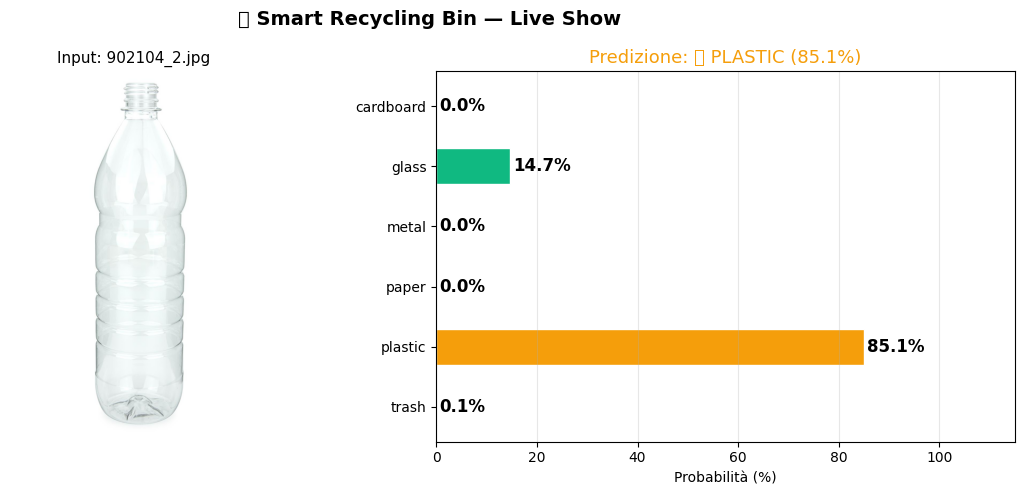


→ RISULTATO: questo oggetto va nel bidone della PLASTIC 🟡
   Confidenza: 85.1%


In [27]:
from PIL import Image



if os.path.exists(IMAGE_PATH):
    img_pil = Image.open(IMAGE_PATH).convert("RGB")
    print(f"Foto caricata: {IMAGE_PATH}")
else:
    print(f"File '{IMAGE_PATH}' non trovato. Genero immagine casuale per demo.")
    arr = (np.random.rand(224, 224, 3) * 255).astype(np.uint8)
    img_pil = Image.fromarray(arr)


preprocess = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])


img_tensor = preprocess(img_pil).unsqueeze(0).to(device)

model.eval()   

with torch.no_grad():
    logits = model(img_tensor)            # vettore di 4 numeri (logit)
    probs  = torch.softmax(logits, dim=1) # converte in probabilità [0,1]
    pred_idx  = probs.argmax(dim=1).item()  # indice della classe con prob max
    pred_class = CLASSES[pred_idx]          # nome della classe
    confidence = probs[0, pred_idx].item()  # valore di confidenza

# ── Visualizzazione ───────────────────────────────────────────────────────────
ICONS = {"plastic": "🟡", "cardboard": "🔵", "glass": "🟢", "metal": "⚪", "paper": "🔵" ,"trash" : "⚪"}
COLORS = {"plastic": "#f59e0b", "cardboard": "#3b82f6", "glass": "#10b981", "metal": "#9ca3af", "paper" : "#ff9e0f", "trash": "#000000"}
fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("🗑️ Smart Recycling Bin — Live Show", fontsize=14, fontweight="bold")

# Immagine originale
ax_img.imshow(img_pil)
ax_img.set_title(f"Input: {IMAGE_PATH if os.path.exists(IMAGE_PATH) else 'immagine casuale'}",
                 fontsize=11)
ax_img.axis("off")

# Barre delle probabilità per ogni classe
class_probs = probs[0].cpu().numpy()
bars = ax_bar.barh(
    CLASSES,
    class_probs * 100,
    color=[COLORS[c] for c in CLASSES],
    edgecolor="white",
    height=0.6,
)

# Etichette percentuali sulle barre
for bar, prob in zip(bars, class_probs):
    ax_bar.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                f"{prob:.1%}", va="center", ha="left", fontsize=12, fontweight="bold")

ax_bar.set_xlim(0, 115)
ax_bar.set_xlabel("Probabilità (%)")
ax_bar.set_title(f"Predizione: {ICONS.get(pred_class, '')} {pred_class.upper()} ({confidence:.1%})",
                 fontsize=13, color=COLORS[pred_class])
ax_bar.grid(axis="x", alpha=0.3)
ax_bar.invert_yaxis()

plt.tight_layout()
plt.savefig("predizione.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n→ RISULTATO: questo oggetto va nel bidone della {pred_class.upper()} {ICONS.get(pred_class, '')}")
print(f"   Confidenza: {confidence:.1%}")

C:\Users\LorenzoBortoluzzi\AppData\Local\Temp\ipykernel_1560\387257205.py:50: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\LorenzoBortoluzzi\AppData\Local\Temp\ipykernel_1560\387257205.py:51: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.savefig("gradcam.png", dpi=150, bbox_inches="tight")


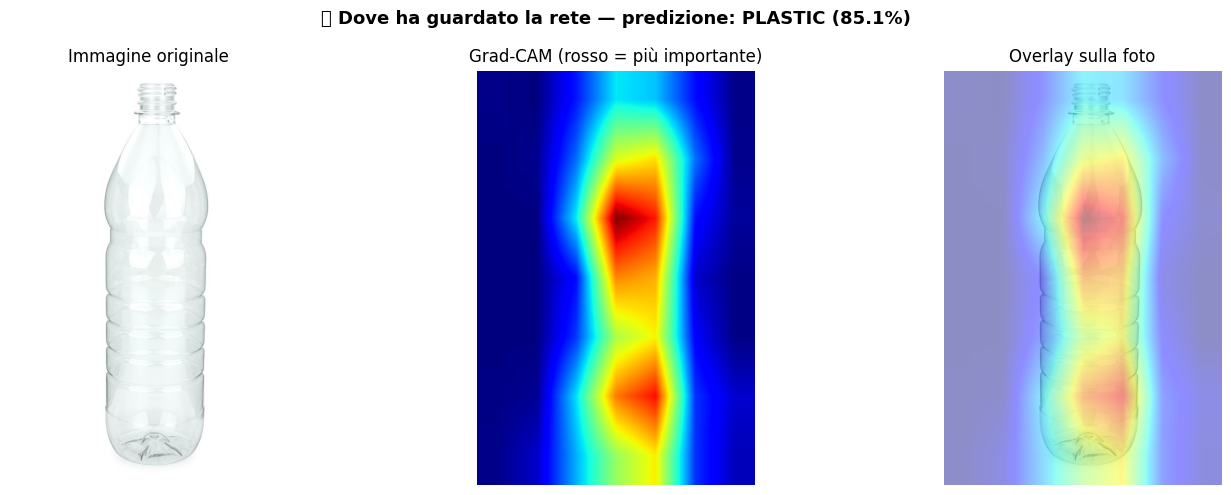

Salvato: gradcam.png
→ Le zone in rosso/giallo sono quelle che hanno spinto la rete verso la classe predetta.


In [28]:
                            
  import torch.nn.functional as F                                                                             
                                                                                                              
  target_layer = model.features[-1]                                                                           
                                                                                                              
  activations, gradients = {}, {}
  h_fwd = target_layer.register_forward_hook(                                                                 
      lambda m, inp, out: activations.update(value=out.detach())                                              
  )                                                                                                           
  h_bwd = target_layer.register_full_backward_hook(                                                           
      lambda m, gi, go: gradients.update(value=go[0].detach())                                                
  )                                                                                                           
                                                                                                              
  model.eval()                                                                                                
  img_t = img_tensor.clone().requires_grad_(True)                         
  logits = model(img_t)                                                                                       
  score  = logits[0, pred_idx]
                                                                                                              
  model.zero_grad()
  score.backward()                                                                                            
  h_fwd.remove(); h_bwd.remove()                                                                              
   
                                                                          
  acts  = activations["value"][0]                                                               
  grads = gradients["value"][0]                                                                  
  weights = grads.mean(dim=(1, 2))                                                                     
  cam = (weights[:, None, None] * acts).sum(dim=0)                                                            
  cam = F.relu(cam)                                                                                           
  cam = cam / (cam.max() + 1e-8)                                                                              
                                                                                                              
  cam_np = cam.cpu().numpy()                                                                                  
  cam_up = np.array(                                                                                          
      Image.fromarray((cam_np * 255).astype(np.uint8))
           .resize(img_pil.size, Image.BILINEAR)                                                              
  ) / 255.0                                                                                                   
                                                                                                              
  fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))                                                  
  fig.suptitle(f"🔍 Dove ha guardato la rete — predizione: {pred_class.upper()} ({confidence:.1%})",          
               fontsize=13, fontweight="bold")                                                                
                                                                                                              
  ax1.imshow(img_pil)                                                                                         
  ax1.set_title("Immagine originale"); ax1.axis("off")                                                        
                                                                                                              
  ax2.imshow(cam_up, cmap="jet")
  ax2.set_title("Grad-CAM (rosso = più importante)"); ax2.axis("off")                                         
                                                                                                              
  ax3.imshow(img_pil)                                                                                         
  ax3.imshow(cam_up, cmap="jet", alpha=0.45)                                                                  
  ax3.set_title("Overlay sulla foto"); ax3.axis("off")                                                        
                                                                                                              
  plt.tight_layout()                                                                                          
  plt.savefig("gradcam.png", dpi=150, bbox_inches="tight")                                                    
  plt.show()                                                                                                  
                                                                                                              
  print(f"Salvato: gradcam.png")                                                                              
  print("→ Le zone in rosso/giallo sono quelle che hanno spinto la rete verso la classe predetta.")

Classi rilevate dalla segmentazione: ['bottle']


C:\Users\LorenzoBortoluzzi\AppData\Local\Temp\ipykernel_1560\1070708837.py:48: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig("segmentazione.png", dpi=150, bbox_inches="tight"); plt.show()
c:\Users\LorenzoBortoluzzi\OneDrive - ITS Angelo Rizzoli\Documenti\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


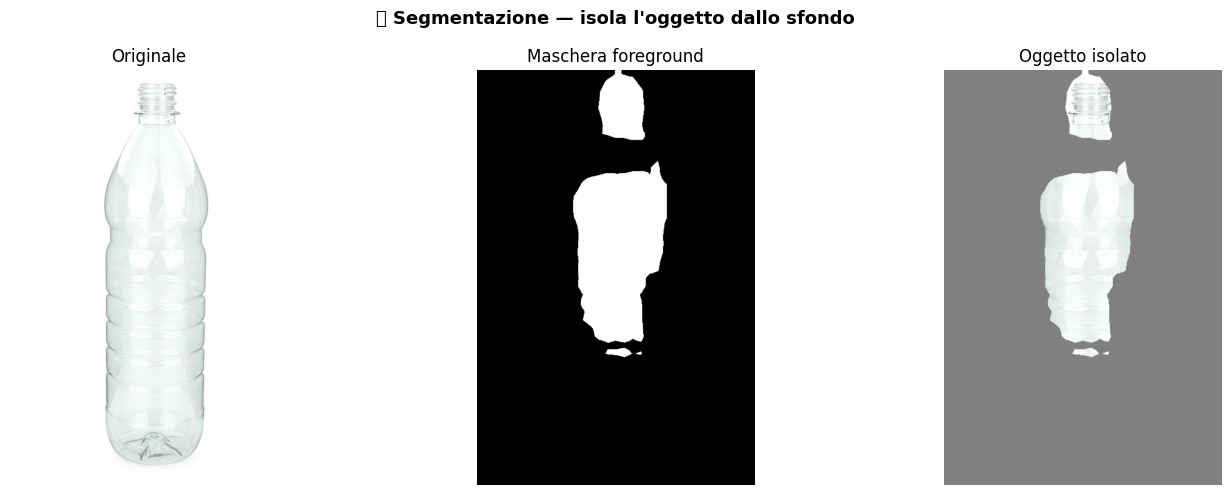


Classificazione foto INTERA:   plastic    (85.1%)
Classificazione oggetto ISOLATO: plastic    (48.7%)


In [20]:
  # ── Segmentazione con DeepLabV3 (MobileNetV3 backbone) ─────────────────────────                           
  # Modello pre-addestrato su COCO (21 classi, inclusa "bottle"). Zero install extra.                         
  from torchvision.models.segmentation import (                                                               
      deeplabv3_mobilenet_v3_large,                                                                           
      DeepLabV3_MobileNet_V3_Large_Weights,                                                                   
  )                                                                                                           
                  
  seg_weights = DeepLabV3_MobileNet_V3_Large_Weights.DEFAULT                                                  
  seg_model   = deeplabv3_mobilenet_v3_large(weights=seg_weights).to(device).eval()
  seg_prep    = seg_weights.transforms()   # pre-processing corretto per questo modello                       
  seg_classes = seg_weights.meta["categories"]   # ['_background_', 'aeroplane', ..., 'bottle', ...]        
                                                                                                              
  # ── Inferenza ──────────────────────────────────────────────────────────────────                           
  with torch.no_grad():                                                                                       
      inp  = seg_prep(img_pil).unsqueeze(0).to(device)                                                        
      logits_seg = seg_model(inp)["out"][0]         # [21, H, W]                                              
      seg_map    = logits_seg.argmax(0).cpu().numpy()  # classe per ogni pixel                                
                                                                                                              
  # Maschera "foreground" = qualunque classe diversa da background (0)                                        
  fg_mask = (seg_map != 0)                                                                                    
                                                                                                              
  # Resize maschera alla dimensione dell'immagine originale                                                   
  from PIL import Image as PILImage
  mask_pil = PILImage.fromarray((fg_mask.astype(np.uint8)) * 255)                                             
  mask_pil = mask_pil.resize(img_pil.size, PILImage.NEAREST)                                                  
  mask_np  = np.array(mask_pil) > 127                                                                         
                                                                                                              
  # Stampa quali classi COCO sono state rilevate (utile per debug)                                            
  detected_ids = np.unique(seg_map)                                                                           
  detected = [seg_classes[i] for i in detected_ids if i != 0]                                                 
  print("Classi rilevate dalla segmentazione:", detected or "(solo background)")                              
                                                                                                              
  # ── Visualizzazione: originale · maschera · oggetto isolato ────────────────────                           
  img_np = np.array(img_pil)                                                                                  
                                                                                                              
  # Applica la maschera all'immagine (sfondo → grigio)                                                        
  isolated = img_np.copy()                                                                                    
  isolated[~mask_np] = 128                                                                                    
                                                                                                              
  fig, axes = plt.subplots(1, 3, figsize=(15, 5))                                                             
  fig.suptitle("🎯 Segmentazione — isola l'oggetto dallo sfondo",                                             
               fontsize=13, fontweight="bold")                                                                
                                                                                                              
  axes[0].imshow(img_pil);  axes[0].set_title("Originale");           axes[0].axis("off")                     
  axes[1].imshow(mask_np, cmap="gray"); axes[1].set_title("Maschera foreground"); axes[1].axis("off")         
  axes[2].imshow(isolated); axes[2].set_title("Oggetto isolato");      axes[2].axis("off")                    
                                                                                                              
  plt.tight_layout(); plt.savefig("segmentazione.png", dpi=150, bbox_inches="tight"); plt.show()              
                                                                                                              
  # ── BONUS: riclassifica l'oggetto isolato e confronta ──────────────────────────                           
  # Rimuovere lo sfondo spesso aumenta la confidenza del classifier.
  isolated_pil = PILImage.fromarray(isolated)                                                                 
  iso_tensor   = preprocess(isolated_pil).unsqueeze(0).to(device)                                             
                                                                                                              
  with torch.no_grad():                                                                                       
      probs_iso = torch.softmax(model(iso_tensor), dim=1)[0]                                                  
      idx_iso   = probs_iso.argmax().item()                                                                   
                                                                                                              
  print(f"\nClassificazione foto INTERA:   {pred_class:<10} ({confidence:.1%})")                              
  print(f"Classificazione oggetto ISOLATO: {CLASSES[idx_iso]:<10} ({probs_iso[idx_iso].item():.1%})")

In [21]:
%pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [26]:
  import cv2                                                                                                  
  import torch    
  import torch.nn.functional as F                                                                             
  import numpy as np                                                                                          
  from PIL import Image
  import time                                                                                                 
                                                                                                              
  # ── Configurazione ────────────────────────────────────────────────────────────                            
  INFER_EVERY_N_FRAMES = 3     # forward + Grad-CAM ogni N frame                                              
  HEATMAP_ALPHA = 0.45         # trasparenza overlay (0 = solo video, 1 = solo heatmap)                       
  CONFIDENCE_THRESHOLD = 0.50                                                                                 
                                                                                                              
  COLORS_BGR = {                                                                                              
      "plastic":   (11, 158, 245),                                                                            
      "cardboard": (246, 130, 59),                                                                            
      "glass":     (129, 199, 16),
      "metal":     (163, 163, 163),                                                                           
      "paper":     (15, 158, 255),
      "trash":     (50, 50, 50),                                                                              
  }               
                                                                                                              
  # ── Setup Grad-CAM: hook sull'ultimo blocco convoluzionale ────────────────────                            
  target_layer = model.features[-1]
  activations, gradients = {}, {}                                                                             
                                                                                                              
  def _fwd_hook(m, inp, out):  activations["v"] = out.detach()                                                
  def _bwd_hook(m, gi, go):    gradients["v"]   = go[0].detach()                                              
                                                                                                              
  h_fwd = target_layer.register_forward_hook(_fwd_hook)                                                       
  h_bwd = target_layer.register_full_backward_hook(_bwd_hook)                                                 
                                                                                                              
  def compute_gradcam(x, class_idx):                                                                          
      """Ritorna una heatmap [H, W] normalizzata in [0, 1] per la classe scelta."""                           
      model.zero_grad()                                                                                       
      logits = model(x)                                                                                       
      score = logits[0, class_idx]                                                                            
      score.backward()                                                                                        
                                                                                                              
      acts  = activations["v"][0]                 # [C, h, w]                                                 
      grads = gradients["v"][0]                   # [C, h, w]                                                 
      weights = grads.mean(dim=(1, 2))            # [C]                                                       
      cam = F.relu((weights[:, None, None] * acts).sum(dim=0))                                                
      cam = cam / (cam.max() + 1e-8)                                                                          
      return cam.cpu().numpy(), logits.detach()                                                               
                                                                                                              
  # ── Apri webcam ───────────────────────────────────────────────────────────────                            
  cap = cv2.VideoCapture(0)                                                                                   
  if not cap.isOpened():                                                                                      
      raise RuntimeError("Webcam non disponibile.")                                                           
                                                                                                              
  model.eval()  # dropout off, ma i gradienti devono comunque fluire                                          
  frame_count = 0                                                                                             
  pred_class, confidence = "...", 0.0                                                                         
  last_heatmap = None   # cache: riutilizzata tra un'inferenza e l'altra
  last_probs   = None                                                                                         
  fps_t0, fps  = time.time(), 0.0                                                                             
                                                                                                              
  print("Premi ESC per uscire.  H = toggle heatmap.")                                                         
  show_heatmap = True                                                                                         
                                                                                                              
  while True:     
      ret, frame = cap.read()                                                                                 
      if not ret:                                                                                             
          break
      frame_count += 1                                                                                        
      H, W = frame.shape[:2]
                                                                                                              
      # ── Ogni N frame: forward + Grad-CAM ──────────────────────────────────────                            
      if frame_count % INFER_EVERY_N_FRAMES == 0:                                                             
          rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)                                                        
          x = preprocess(Image.fromarray(rgb)).unsqueeze(0).to(device)                                        
          x.requires_grad_(True)   # serve per la backward della Grad-CAM                                     
                                                                                                              
          cam_small, logits = compute_gradcam(x, class_idx=None or torch.softmax(model(x),                    
  dim=1).argmax(1).item())                                                                                    
          probs = torch.softmax(logits, dim=1)[0]                                                             
          idx = probs.argmax().item()                                                                         
          pred_class = CLASSES[idx]
          confidence = probs[idx].item()                                                                      
          last_probs = probs.detach().cpu().numpy()
                                                                                                              
          # Upscale heatmap alla dimensione del frame                                                         
          last_heatmap = cv2.resize(cam_small, (W, H), interpolation=cv2.INTER_LINEAR)                        
                                                                                                              
          now = time.time()                                                                                   
          fps = INFER_EVERY_N_FRAMES / (now - fps_t0)                                                         
          fps_t0 = now                                                                                        
                  
      # ── Overlay heatmap sul frame ─────────────────────────────────────────────                            
      display = frame.copy()
      if show_heatmap and last_heatmap is not None:                                                           
          heat_u8 = np.uint8(255 * last_heatmap)
          heat_color = cv2.applyColorMap(heat_u8, cv2.COLORMAP_JET)                                           
          display = cv2.addWeighted(display, 1 - HEATMAP_ALPHA, heat_color, HEATMAP_ALPHA, 0)                 
                                                                                                              
      # ── Banner con classe + confidenza + FPS ──────────────────────────────────                            
      color = COLORS_BGR.get(pred_class, (255, 255, 255))                                                     
      label = f"{pred_class.upper()} ({confidence:.0%})"                                                      
      if confidence < CONFIDENCE_THRESHOLD:                                                                   
          label, color = f"? {label}", (100, 100, 100)                                                        
                                                                                                              
      cv2.rectangle(display, (0, 0), (W, 60), (0, 0, 0), -1)                                                  
      cv2.putText(display, label, (15, 42),                                                                   
                  cv2.FONT_HERSHEY_SIMPLEX, 1.1, color, 2)                                                    
      cv2.putText(display, f"{fps:.1f} FPS", (W - 130, 42),                                                   
                  cv2.FONT_HERSHEY_SIMPLEX, 0.7, (200, 200, 200), 2)                                          
                                                                                                              
      # ── Barre probabilità ─────────────────────────────────────────────────────                            
      if last_probs is not None:                                                                              
          y0 = H - 25 * len(CLASSES) - 10                                                                     
          for i, cls in enumerate(CLASSES):                                                                   
              p = float(last_probs[i])                                                                        
              y = y0 + i * 25                                                                                 
              cv2.rectangle(display, (10, y), (10 + int(p * 200), y + 18),                                    
                            COLORS_BGR.get(cls, (255, 255, 255)), -1)                                         
              cv2.putText(display, f"{cls} {p:.0%}", (220, y + 14),                                           
                          cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)                                  
                                                                                                              
      cv2.imshow("Smart Recycling Bin - Live + Grad-CAM", display)                                            
                                                                                                              
      key = cv2.waitKey(1) & 0xFF                                                                             
      if key == 27:          # ESC
          break                                                                                               
      elif key == ord("h"):  # H = toggle heatmap                                                             
          show_heatmap = not show_heatmap                                                                     
                                                                                                              
  # ── Cleanup ───────────────────────────────────────────────────────────────────                            
  h_fwd.remove(); h_bwd.remove()                                                                              
  cap.release()                                                                                               
  cv2.destroyAllWindows()

Premi ESC per uscire.  H = toggle heatmap.


---
## 💾 Slide 9 — Salvataggio del modello

Salviamo i pesi del modello per poterlo riutilizzare senza riaddestrarlo.  
`.state_dict()` salva solo i pesi (non l'architettura) → file più leggero.

In [23]:
# ── Salvataggio ───────────────────────────────────────────────────────────────
# Salviamo sia i pesi che i metadati utili
checkpoint = {
    "model_state_dict": model.state_dict(),  # i pesi del modello
    "optimizer_state_dict": optimizer.state_dict(),
    "history": history,
    "classes": CLASSES,
    "num_epochs": NUM_EPOCHS,
    "test_accuracy": float(test_acc),
}

torch.save(checkpoint, "smart_recycling_bin.pth")
print("Modello salvato: smart_recycling_bin.pth")

# ── Caricamento (per uso futuro) ──────────────────────────────────────────────
# Per ricaricare il modello in un altro notebook:
#
# from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
# model = mobilenet_v2(weights=None)  # architettura senza pesi
# model.classifier = nn.Sequential(...) # stessa architettura del classifier
# checkpoint = torch.load("smart_recycling_bin.pth")
# model.load_state_dict(checkpoint["model_state_dict"])
# model.eval()  # SEMPRE prima dell'inferenza

print("\nRiepilogo finale:")
print(f"  Modello:        MobileNetV2 + classificatore custom")
print(f"  Classi:         {CLASSES}")
print(f"  Epoche:         {NUM_EPOCHS}")
print(f"  Test Accuracy:  {test_acc:.2%}")
print(f"  Tecnica chiave: Transfer Learning + Data Augmentation + Dropout")

Modello salvato: smart_recycling_bin.pth

Riepilogo finale:
  Modello:        MobileNetV2 + classificatore custom
  Classi:         ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
  Epoche:         15
  Test Accuracy:  79.74%
  Tecnica chiave: Transfer Learning + Data Augmentation + Dropout


---
## 🎓 Riepilogo concettuale

| Concetto | Dove l'abbiamo usato | Fonte |
|---|---|---|
| Neuroni, pesi, bias | Ogni layer lineare | Lezione 1, sezione 1 |
| Funzioni di attivazione (ReLU) | Classificatore custom | Lezione 1, sezione 2 |
| Strato denso (fully connected) | `nn.Linear` | Lezione 1, sezione 3 |
| MLP / architettura a layer | Struttura di MobileNetV2 | Lezione 1, sezione 4 |
| Training set / Feature / Label | `ImageFolder`, split 70/15/15 | Lezione 1, sezione 5 |
| Softmax nell'output | `CrossEntropyLoss` (implicita) | Lezione 1, sezione 6 |
| CrossEntropy / MSE | `nn.CrossEntropyLoss()` | Lezione 1, sezione 7 |
| Gradiente e discesa | `loss.backward()` + `optimizer.step()` | Lezione 1, sezione 8 |
| Dropout | `nn.Dropout(p=0.3)` nel classificatore | `dropout.ipynb` |
| Data Augmentation | `train_transform` | Notebook 10 marzo |

---
*Smart Recycling Bin · CNN · Transfer Learning · PyTorch*